#### Load cleaned data  
Data was cleaned by median imputation which means empty cells were filled with the median value for the column.  The first five rows of the dataset are shown.  Values that were NaN in the raw data have been replaced with the median column value.

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/water_potability_clean.csv")
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.036752,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,333.073546,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,333.073546,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [21]:
count = df["Potability"].value_counts()
proportion = df["Potability"].value_counts(normalize=True)

df_potable = pd.DataFrame({
    "potable_count": count,
    "potable_proportion": proportion
})

df_potable

,potable_count,potable_proportion
Potability,,
0,1998,0.60989
1,1278,0.39011


There are 1,998 non-potable samples and 1,278 potable samples, resulting in an approximate class distribution of 61% to 39%. This indicates a moderate class imbalance that should be considered when evaluating model performance.

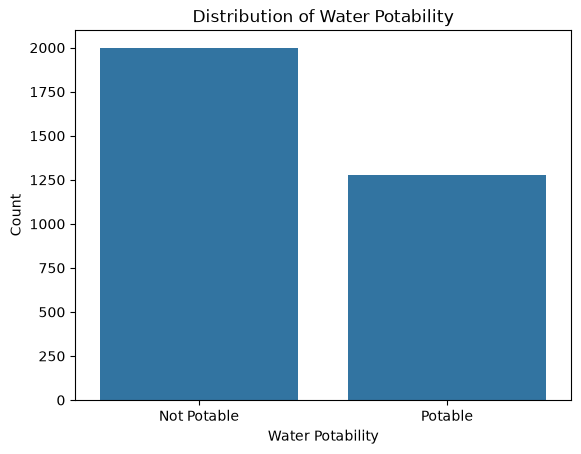

In [10]:
sns.countplot(data=df, x="Potability")

plt.xticks([0, 1], ["Not Potable", "Potable"])
plt.xlabel("Water Potability")
plt.ylabel("Count")
plt.title("Distribution of Water Potability")

plt.show()

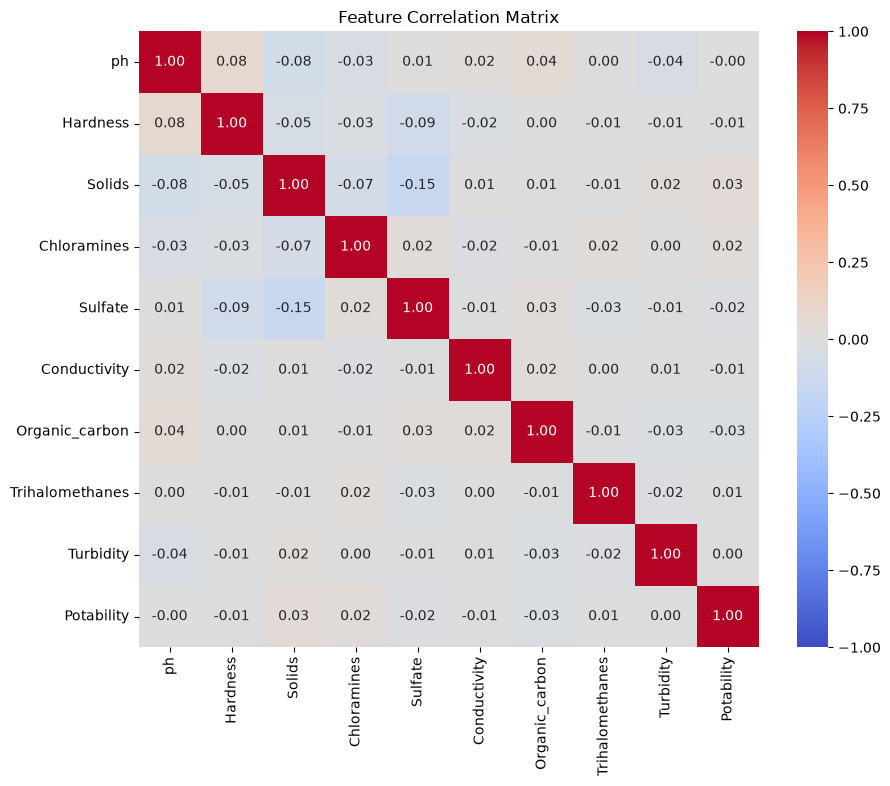

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")
plt.show()

#### Correlation heatmap observation
The correlation heatmap shows that none of the features are strongly correlated with one another. The strongest relationships are weak to moderate and occur among pH, Hardness, Solids, and Sulfate, suggesting some association among these water chemistry measurements.

Correlations between the features and the target variable (Potability) are very weak. The largest correlations are Chloramines (0.03) and Organic_carbon (-0.03), indicating that no single feature has a strong linear relationship with water potability. This suggests that predicting potability will likely require combining information from multiple features rather than relying on any individual measurement.

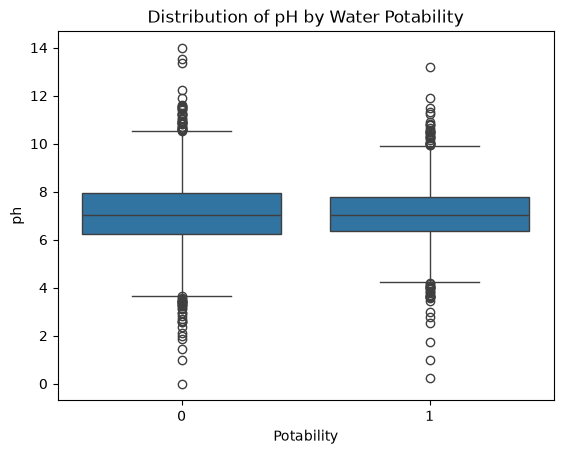

In [22]:
sns.boxplot(
    data=df,
    x="Potability",
    y="ph"
)
plt.title("Distribution of pH by Water Potability")
plt.show()

#### pH Distribution by Potability boxplot observations
Most water samples have pH values between approximately 6 and 8, regardless of potability. The median pH is similar for both potable and non-potable samples, indicating little difference in the central tendency of the two groups.  

The interquartile range (the box) is slightly narrower for potable samples, suggesting that the middle 50% of potable samples have less variation in pH than non-potable samples.  

Both groups contain numerous outliers, with non-potable samples exhibiting slightly more extreme pH values. This suggests that non-potable water is somewhat more likely to include unusually low or high pH measurements.

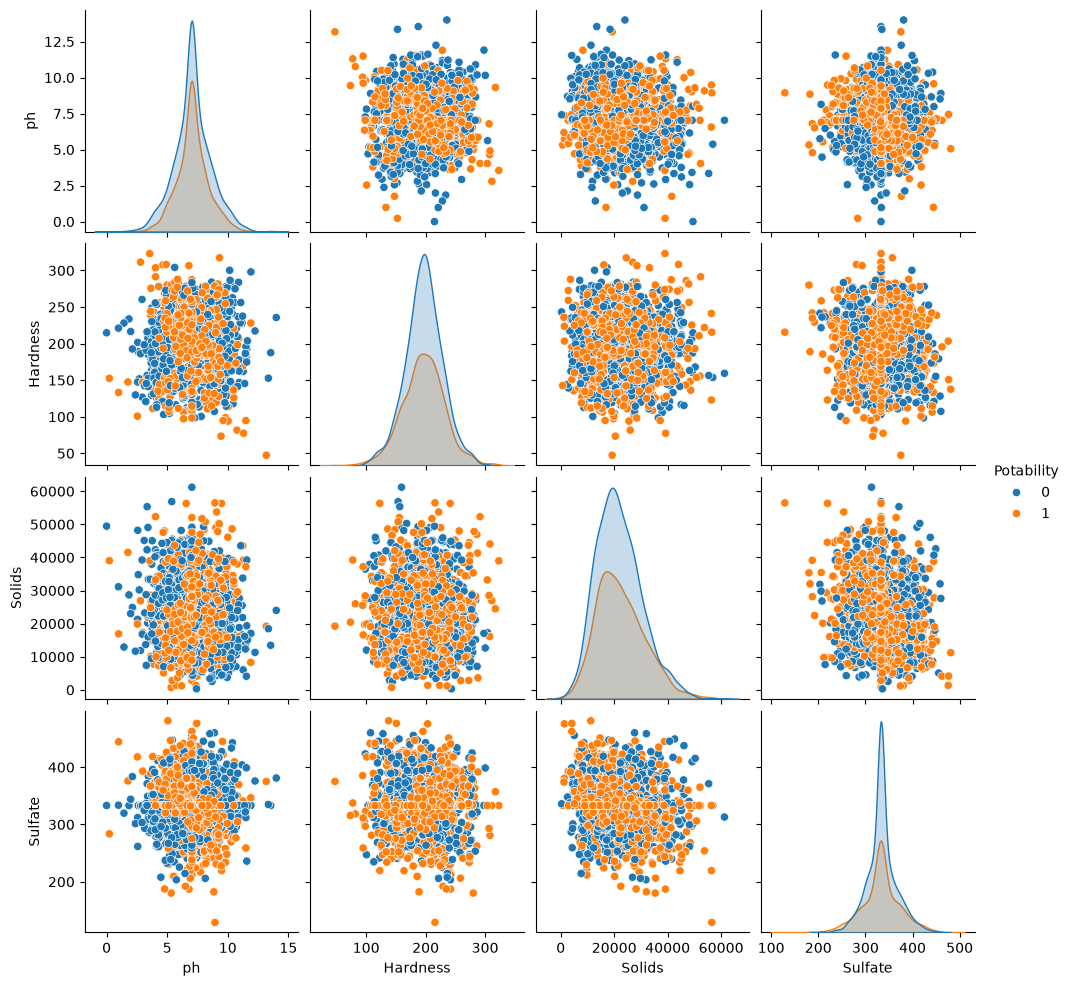

In [25]:
sns.pairplot(
    df,
    vars=["ph", "Hardness", "Solids", "Sulfate"],
    hue="Potability"
)

#### Water Quality Feature Relationships by Potability
The pairplot shows significant overlap between potable and non-potable samples across all feature pairs. No clear class separation is visible, consistent with weak correlations observed in the dataset. This suggests that potability prediction will require a multivariate, likely nonlinear model.